# ⚡ Energy Lab — Partie 1 : le frigo seul la nuit

Ce notebook introduit les outils un par un (matplotlib, numpy, pandas)
à travers un cas simple : analyser le signal d'un frigo isolé.

> `Shift+Enter` pour exécuter une cellule.

![title](pictures/cyberpunk_engraving_title_1784108576637.png)


In [1]:
import random as _random_qcm
import ipywidgets as w
from IPython.display import display

_RELANCES_HUMOUR = [
    "Le compresseur du frigo a plus de constance que cette réponse.",
    "Pas grave, même le capteur Linky se trompe parfois (façon de parler).",
    "On va dire que c'était un test de tes réflexes, pas de tes connaissances.",
    "Presque ! Enfin... pas vraiment, mais l'intention y était.",
    "Aïe. Même le bruit gaussien ±8 W est plus proche de la vérité.",
    "Retente ta chance, le frigo ne t'en voudra pas.",
]

def qcm(question, options, correct, explication=""):
    """
    Affiche un QCM interactif.
    correct : index (int) ou liste d'index de la/des bonne(s) réponse(s).
    """
    if isinstance(correct, int):
        correct = [correct]

    boutons = w.RadioButtons(options=options, layout=w.Layout(width='100%'))
    sortie  = w.Output()
    titre   = w.HTML(f"<b>❓ {question}</b>")

    def verifier(change):
        idx = options.index(change['new'])
        sortie.clear_output()
        with sortie:
            if idx in correct:
                display(w.HTML(
                    f"<div style='padding:8px;border-radius:6px;background:#d4edda;color:#155724'>"
                    f"✅ <b>Correct !</b> {explication}</div>"
                ))
            else:
                humour = _random_qcm.choice(_RELANCES_HUMOUR)
                display(w.HTML(
                    f"<div style='padding:8px;border-radius:6px;background:#f8d7da;color:#721c24'>"
                    f"❌ <b>Pas tout à fait.</b> {humour}<br>"
                    f"<b>Pourquoi ce n'est pas ça :</b> {explication}</div>"
                ))

    boutons.observe(verifier, names='value')
    display(w.VBox([titre, boutons, sortie]))

print("✅ Fonction qcm() prête — les QCM s'afficheront au fil du notebook.")

✅ Fonction qcm() prête — les QCM s'afficheront au fil du notebook.


---
# Partie 1 — Le frigo seul la nuit

## 1.1 · Le signal : une liste de mesures

La nuit, seul le frigo tourne. Son compresseur fait des cycles :
- **ON** (~10 min) : le compresseur chauffe, consommation ~150 W
- **OFF** (~20 min) : repos, consommation ~30 W (veille électronique)

On simule 8 heures de mesures (de 23h à 7h), 1 mesure toutes les 10 secondes.

In [2]:
import random

random.seed(42)

# Paramètres du frigo
DUREE_ON_s  = 10 * 60   # 10 minutes ON (valeur théorique moyenne)
DUREE_OFF_s = 20 * 60   # 20 minutes OFF (valeur théorique moyenne)
PUISSANCE_ON  = 150      # Watts quand le compresseur tourne
PUISSANCE_OFF =  30      # Watts en veille
BRUIT = 8                # variation aléatoire ±8 W
ALEA_DUREE = 0.25        # ±25% de variation aléatoire sur la durée de chaque cycle

# Générer 8h de signal (1 point = 10 secondes)
N = 8 * 3600 // 10      # 2880 points
signal = []

# Un vrai frigo ne fait pas des cycles parfaitement réguliers : on tire
# une durée ON et une durée OFF différente à chaque cycle, autour de la
# valeur théorique (± ALEA_DUREE).
i = 0
en_on = True
duree_restante = round(DUREE_ON_s * random.uniform(1 - ALEA_DUREE, 1 + ALEA_DUREE)) // 10
while i < N:
    if duree_restante <= 0:
        en_on = not en_on
        base = DUREE_ON_s if en_on else DUREE_OFF_s
        duree_restante = round(base * random.uniform(1 - ALEA_DUREE, 1 + ALEA_DUREE)) // 10
    p = PUISSANCE_ON if en_on else PUISSANCE_OFF
    p += random.gauss(0, BRUIT)
    signal.append(max(0, p))
    duree_restante -= 1
    i += 1

# Afficher les premières valeurs pour comprendre la structure
print(f"Nombre de mesures : {len(signal)}")
print(f"Durée couverte    : {len(signal) * 10 / 3600:.0f} heures")
print(f"Premières valeurs (W) : {[round(v) for v in signal[:8]]} ...")
print(f"Valeur min : {min(signal):.0f} W  |  max : {max(signal):.0f} W")

Nombre de mesures : 2880
Durée couverte    : 8 heures
Premières valeurs (W) : [156, 151, 152, 163, 142, 135, 157, 154] ...
Valeur min : 0 W  |  max : 174 W


In [3]:
qcm(
    "On génère 1 mesure toutes les 10 secondes. Combien de points couvre 1 heure de signal ?",
    ["60 points", "360 points", "600 points", "3 600 points"],
    correct=1,
    explication="1 heure = 3 600 secondes. À raison d'1 point toutes les 10 s : 3 600 ÷ 10 = 360 points."
)

In [4]:
qcm(
    "En lisant le code Python ci-dessus, le signal généré est-il un signal carré parfait ou un signal bruité ?",
    [
        "Un signal carré parfait — le compresseur passe instantanément de 30 W à 150 W",
        "Un signal bruité — chaque valeur varie aléatoirement autour de 30 W ou 150 W",
        "Un signal sinusoïdal — la puissance oscille doucement entre 30 W et 150 W",
        "Un signal constant — toujours à 90 W (la moyenne)",
    ],
    correct=1,
    explication="La ligne <code>random.gauss(0, BRUIT)</code> ajoute un bruit gaussien "
                "(±8 W) à chaque mesure. C'est volontaire : les vraies mesures du compteur "
                "Linky ne sont jamais parfaitement stables non plus."
)

## 1.2 · Visualiser avec matplotlib

On a 2880 mesures dans une liste. Impossible de voir quoi que ce soit en les lisant.  
On a besoin de **matplotlib** — la bibliothèque de référence pour tracer des graphiques en Python.

```
import matplotlib.pyplot as plt
```

`pyplot` est l'interface principale : `plt.plot()`, `plt.show()`, etc.

![section1](pictures/cyberpunk_engraving_section1_1784108662188.png)


In [5]:
qcm(
    "À quoi sert matplotlib dans ce notebook ?",
    [
        "Faire des calculs sur les mesures de puissance",
        "Stocker les mesures dans un tableau structuré",
        "Tracer le signal pour le visualiser",
        "Détecter les appareils automatiquement",
    ],
    correct=2,
    explication="matplotlib sert uniquement à la visualisation (graphiques). "
                "Les calculs sont faits avec numpy, le stockage avec pandas."
)

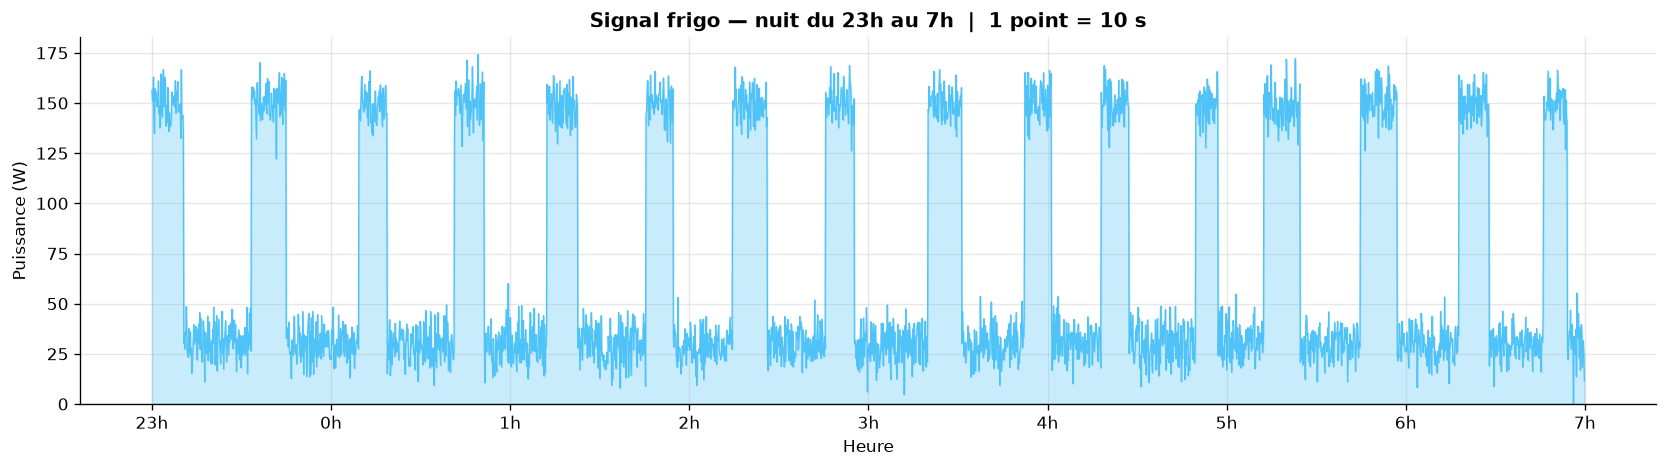

On voit clairement les cycles ON (~150 W) et OFF (~30 W) du compresseur.


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Axe X en heures écoulées depuis 23h00 (0 = 23h, 1 = 0h, ..., 8 = 7h)
# On évite le wrap minuit qui crée un trait diagonal dans fill_between
heures = [i * 10 / 3600 for i in range(N)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(heures, signal, color='#4fc3f7', lw=0.8)
ax.fill_between(heures, signal, alpha=0.3, color='#4fc3f7')
ax.set_xlabel('Heure')
ax.set_ylabel('Puissance (W)')
ax.set_title('Signal frigo — nuit du 23h au 7h  |  1 point = 10 s', fontweight='bold')
ax.set_ylim(bottom=0)
ax.set_xticks(range(9))
ax.set_xticklabels(['23h', '0h', '1h', '2h', '3h', '4h', '5h', '6h', '7h'])
plt.tight_layout()
plt.show()

print('On voit clairement les cycles ON (~150 W) et OFF (~30 W) du compresseur.')

In [7]:
qcm(
    "L'axe X commence à 0 pour 23h00 et avance d'1 unité par heure. "
    "Quelle ligne ajouter pour ne voir que la courbe de 4h à 5h du matin ?",
    [
        "ax.set_xlim(4, 5)",
        "ax.set_xlim(5, 6)",
        "ax.set_ylim(4, 5)",
        "ax.set_xlabel('4h', '5h')",
    ],
    correct=1,
    explication="23h = 0, minuit = 1, 1h = 2, 2h = 3, 3h = 4, 4h = 5, 5h = 6. "
                "Donc <code>ax.set_xlim(5, 6)</code> cadre exactement sur 4h–5h du matin. "
                "set_ylim contrôle l'axe vertical (puissance), pas le temps."
)

## 1.3 · Calculer avec numpy

On veut analyser le signal : calculer la moyenne, détecter les passages ON/OFF, etc.  
Avec une liste Python, ça demande des boucles fastidieuses.

**numpy** introduit le concept d'**array** : un vecteur de nombres sur lequel  
les opérations s'appliquent à tous les éléments à la fois, sans boucle.

```python
import numpy as np
signal_np = np.array(signal)   # conversion liste → array
signal_np * 2                  # multiplie chaque valeur par 2
signal_np > 90                 # True/False pour chaque valeur
signal_np.mean()               # moyenne de tout le vecteur
```

Numpy est aussi beaucoup plus rapide que les boucles Python (calculs en C en interne).

![section2](pictures/cyberpunk_engraving_section2_1784108683408.png)


In [8]:
qcm(
    "Que retourne s > 90 si s est un array numpy contenant [30, 150, 28, 145] ?",
    [
        "True (car la moyenne est > 90)",
        "[False, True, False, True]  — un booléen par élément",
        "Une erreur : on ne peut pas comparer un array à un nombre",
        "Le nombre d'éléments supérieurs à 90",
    ],
    correct=1,
    explication="Avec numpy, l'opérateur > s'applique élément par élément et retourne un array de booléens. "
                "C'est ce qu'on appelle la vectorisation — pas de boucle nécessaire."
)

=== Statistiques du signal ===
  Moyenne  : 70.7 W
  Médiane  : 35.7 W
  Écart-type : 57.3 W
  Min / Max  : 0 W / 174 W

=== État du compresseur ===
  Points ON  : 975 / 2880 (34%)
  Puissance moyenne ON  : 149.9 W
  Puissance moyenne OFF : 30.1 W


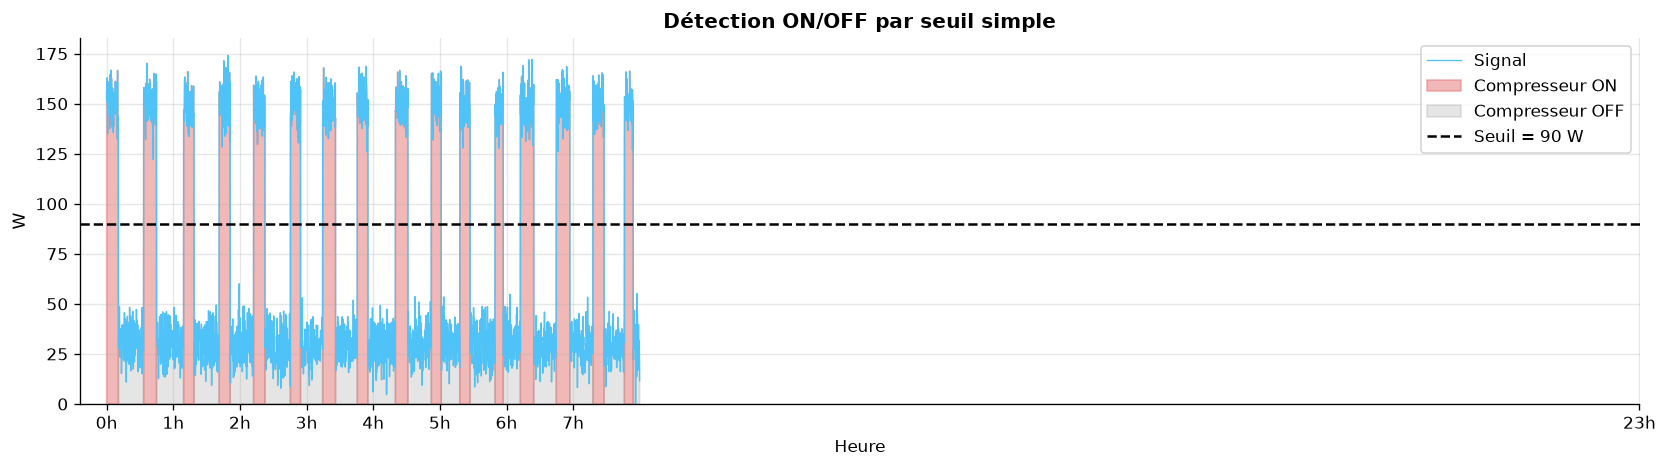

In [9]:
import numpy as np

s = np.array(signal)   # liste Python → array numpy

# Statistiques de base — une ligne chacune, pas de boucle
print("=== Statistiques du signal ===")
print(f"  Moyenne  : {s.mean():.1f} W")
print(f"  Médiane  : {np.median(s):.1f} W")
print(f"  Écart-type : {s.std():.1f} W")
print(f"  Min / Max  : {s.min():.0f} W / {s.max():.0f} W")

# Seuil ON/OFF : mi-chemin entre les deux niveaux
SEUIL = 90   # W — au-dessus = compresseur ON

en_marche = s > SEUIL                          # array de True/False
print(f"\n=== État du compresseur ===")
print(f"  Points ON  : {en_marche.sum()} / {len(s)} ({en_marche.mean():.0%})")
print(f"  Puissance moyenne ON  : {s[en_marche].mean():.1f} W")
print(f"  Puissance moyenne OFF : {s[~en_marche].mean():.1f} W")

# Visualiser le masque ON/OFF
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(heures, s, color='#4fc3f7', lw=0.8, label='Signal')
ax.fill_between(heures, s, where=en_marche,  alpha=0.5, color='#e57373', label='Compresseur ON')
ax.fill_between(heures, s, where=~en_marche, alpha=0.2, color='gray',    label='Compresseur OFF')
ax.axhline(SEUIL, color='black', lw=1.5, ls='--', label=f'Seuil = {SEUIL} W')
ax.set_xlabel('Heure')
ax.set_ylabel('W')
ax.set_title('Détection ON/OFF par seuil simple', fontweight='bold')
ax.set_ylim(bottom=0)
ax.set_xticks([23, 0, 1, 2, 3, 4, 5, 6, 7])
ax.set_xticklabels(['23h', '0h', '1h', '2h', '3h', '4h', '5h', '6h', '7h'])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

**À toi de jouer** — utilise la cellule vide ci-dessous pour tester par toi-même
l'indexation booléenne avec `en_marche` et `~en_marche` (négation : ON devient OFF et vice versa).
Quelques idées à essayer :
- `s[en_marche][:10]` — les 10 premières valeurs mesurées quand le compresseur tournait
- `len(s[en_marche])` vs `en_marche.sum()` — est-ce pareil ?
- `s[~en_marche].max()` — la puissance max mesurée compresseur éteint (bruit max)
- Que donne `s[en_marche == False]` par rapport à `s[~en_marche]` ?

In [10]:
# Cellule libre — expérimente ici avec s[en_marche] et s[~en_marche]



In [11]:
qcm(
    "Que fait `s[en_marche]` sachant que `en_marche` est un array de booléens de même taille que `s` ?",
    [
        "Une erreur : on ne peut pas indexer un array avec des booléens",
        "Elle sélectionne uniquement les valeurs de s là où en_marche vaut True",
        "Elle retourne le nombre de True dans en_marche",
        "Elle remplace les False par des zéros dans s",
    ],
    correct=1,
    explication="C'est de l'<b>indexation booléenne</b> : <code>s[en_marche]</code> garde uniquement "
                "les éléments de <code>s</code> aux positions où <code>en_marche</code> est True — "
                "donc les puissances mesurées quand le compresseur tournait."
)

## 1.4 · Mesurer les cycles avec numpy

On sait quand le compresseur est ON ou OFF. Maintenant on veut mesurer :
- La **durée** de chaque phase ON et OFF
- Le **duty cycle** : fraction du temps où il tourne

`np.diff()` calcule la différence entre éléments consécutifs — utile pour détecter les transitions.

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Transitions détectées : 15 démarrages, 16 arrêts

Durées des phases ON (15 cycles complets) :
  Moyenne  : 10.1 min
  Min/Max  : 7.5 min / 12.3 min

Duty cycle (fraction du temps ON) : 34%


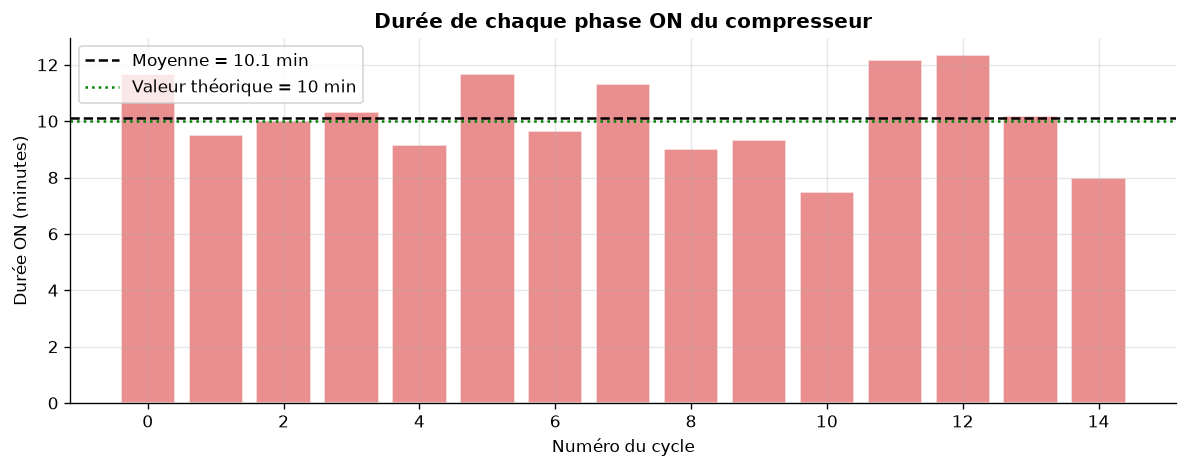


Le bruit aléatoire, et maintenant aussi la variation de durée des cycles,
fait varier les durées ON autour de la valeur théorique — comme un vrai frigo.


In [12]:
# np.diff() : différence entre points consécutifs du masque ON/OFF
# True→False = -1 (fin d'un cycle ON)
# False→True = +1 (début d'un cycle ON)
transitions = np.diff(en_marche.astype(int))

print(transitions[:20])  # les 20 premières transitions

# Indices où l'état change
debits_ON  = np.where(transitions == 1)[0]    # False→True : compresseur démarre
fins_ON    = np.where(transitions == -1)[0]   # True→False : compresseur s'arrête

print(f"Transitions détectées : {len(debits_ON)} démarrages, {len(fins_ON)} arrêts")

# Le signal peut commencer en plein milieu d'un cycle ON : dans ce cas, le
# tout premier "arrêt" arrive avant le premier "démarrage" observé, et il
# ne correspond à aucun démarrage complet (on ne connaît pas son début).
# On l'écarte pour ne garder que des arrêts qui suivent un démarrage.
if len(debits_ON) and len(fins_ON):
    fins_ON = fins_ON[fins_ON > debits_ON[0]]

# Calculer la durée de chaque phase ON complète
# Aligner : chaque démarrage avec le premier arrêt qui le suit
paires = []
for d in debits_ON:
    apres = fins_ON[fins_ON > d]
    if len(apres) > 0:
        paires.append((d, apres[0]))

durees_on_s  = [(f - d) * 10 for d, f in paires]   # × 10 car 1 point = 10 s

print(f"\nDurées des phases ON ({len(durees_on_s)} cycles complets) :")
print(f"  Moyenne  : {np.mean(durees_on_s)/60:.1f} min")
print(f"  Min/Max  : {min(durees_on_s)/60:.1f} min / {max(durees_on_s)/60:.1f} min")
print(f"\nDuty cycle (fraction du temps ON) : {en_marche.mean():.0%}")

# Visualisation des cycles individuels
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(durees_on_s)), [d/60 for d in durees_on_s],
       color='#e57373', alpha=0.8, edgecolor='white')
ax.axhline(np.mean(durees_on_s)/60, color='black', ls='--', lw=1.5,
           label=f'Moyenne = {np.mean(durees_on_s)/60:.1f} min')
ax.axhline(DUREE_ON_s/60, color='green', ls=':', lw=1.5,
           label=f'Valeur théorique = {DUREE_ON_s//60} min')
ax.set_xlabel('Numéro du cycle')
ax.set_ylabel('Durée ON (minutes)')
ax.set_title('Durée de chaque phase ON du compresseur', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nLe bruit aléatoire, et maintenant aussi la variation de durée des cycles,")
print("fait varier les durées ON autour de la valeur théorique — comme un vrai frigo.")

**À toi de jouer** — utilise la cellule vide ci-dessous pour tester `np.diff()` et `np.where()`
sur `en_marche` (ou sur un petit array que tu inventes toi-même).
Quelques idées à essayer :
- `np.diff([0, 0, 1, 1, 0, 1])` — que donne cette différence, et pourquoi ?
- `np.where(np.array([0, 0, 1, 1, 0, 1]) == 1)` — que retourne `np.where` exactement ?
- `transitions[:30]` — regarde une portion plus longue, repères-tu les +1 et -1 ?
- `len(debits_ON)` vs `len(fins_ON)` — sont-ils toujours égaux ? pourquoi ?

In [13]:
# Cellule libre — expérimente ici avec np.diff() et np.where()



In [14]:
qcm(
    "Soit `mask = [False, False, True, True, False, True]`. "
    "Que fait `np.diff(mask.astype(int))` ?",
    [
        "Il retourne la liste inchangée",
        "Il retourne [0, 1, 0, -1, 1] : +1 à chaque False→True, -1 à chaque True→False",
        "Il retourne le nombre total de True",
        "Il retourne une erreur car mask contient des booléens",
    ],
    correct=1,
    explication="<code>np.diff()</code> calcule la différence entre éléments consécutifs. "
                "Sur un array de 0/1, un passage 0→1 donne +1 (démarrage) et un passage 1→0 "
                "donne -1 (arrêt) — c'est exactement ce qu'on utilise pour détecter les transitions ON/OFF."
)

In [15]:
qcm(
    "Le compresseur tourne 10 min sur 30 min. Quel est son duty cycle ?",
    ["10 %", "20 %", "33 %", "50 %"],
    correct=2,
    explication="Duty cycle = temps ON / temps total = 10 min / 30 min ≈ 33 %. "
                "C'est une feature clé : elle caractérise le rythme des cycles sans dépendre de la puissance absolue."
)

## 1.5 · Structurer avec pandas

Jusqu'ici on a un array numpy et une liste de `heures`.  
Mais les vraies données du compteur Linky ont des **horodatages ISO 8601** :  
`"2026-07-06T23:00:00Z"`, `"2026-07-06T23:00:10Z"`, ...

**pandas** permet de manipuler des **tableaux structurés** (DataFrames) avec :
- Des colonnes nommées (`timestamp`, `valeur_W`, `etat`)
- Des filtres puissants par date/heure
- Des opérations de groupement (par heure, par cycle...)

C'est exactement le format produit par `data_sync.py` quand on récupère les données du Pi.

> **Remarque** : rien de ce qui suit n'est *impossible* à faire avec numpy seul (on pourrait
> garder deux arrays parallèles, `timestamps` et `valeurs`, et écrire ses propres boucles de
> filtre/groupement). Mais pandas est l'outil standard dès qu'on manipule des données avec des
> horodatages et des colonnes nommées — c'est ce que tu retrouveras dans quasi tout le code
> data science réel, y compris `data_sync.py` ici. On l'introduit maintenant pour que tu sois
> à l'aise avec son vocabulaire (`DataFrame`, `resample`, `groupby`) avant la Partie 2.

In [16]:
qcm(
    "Quelle est la principale différence entre un array numpy et un DataFrame pandas ?",
    [
        "numpy est plus rapide, donc on doit toujours préférer numpy",
        "pandas ajoute des colonnes nommées et des index (notamment des horodatages)",
        "pandas ne peut stocker que du texte, numpy que des nombres",
        "Il n'y a pas de différence, ce sont deux noms pour la même chose",
    ],
    correct=1,
    explication="Un array numpy est un tableau de nombres bruts (rapide, sans étiquettes). "
                "Un DataFrame pandas y ajoute des noms de colonnes, un index (souvent temporel), "
                "et des opérations de haut niveau : filtre, groupby, resample par heure, etc."
)

In [17]:
import pandas as pd
from datetime import datetime, timedelta, timezone

# Construire les horodatages : 23h00 le 06/07/2026, 1 point toutes les 10 s
t0 = datetime(2026, 7, 6, 23, 0, 0, tzinfo=timezone.utc)
timestamps = [(t0 + timedelta(seconds=i * 10)).strftime('%Y-%m-%dT%H:%M:%SZ')
              for i in range(N)]

# DataFrame : même format que data_sync.py produit
df = pd.DataFrame({
    'timestamp': timestamps,
    'valeur_W':  [round(v) for v in signal],
})

print("Structure du DataFrame :")
print(df.head(8).to_string(index=False))
print(f"\n{len(df)} lignes, {len(df.columns)} colonnes")

# Convertir la colonne timestamp en vrai type datetime (pour filtrer par heure)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

# Exemple : extraire seulement la première heure (23h → minuit)
premiere_heure = df[df['timestamp'] < pd.Timestamp('2026-07-07T00:00:00Z')]
print(f"\nPoints dans la première heure : {len(premiere_heure)}")
print(f"Puissance moyenne 23h-0h : {premiere_heure['valeur_W'].mean():.1f} W")

# Statistiques par heure via resample (groupement temporel automatique)
df_heure = df.set_index('timestamp').resample('h')['valeur_W'].agg(['mean', 'min', 'max'])
print("\nMoyenne, min, max par heure :")
print(df_heure.round(0).to_string())

Structure du DataFrame :
           timestamp  valeur_W
2026-07-06T23:00:00Z       156
2026-07-06T23:00:10Z       151
2026-07-06T23:00:20Z       152
2026-07-06T23:00:30Z       163
2026-07-06T23:00:40Z       142
2026-07-06T23:00:50Z       135
2026-07-06T23:01:00Z       157
2026-07-06T23:01:10Z       154

2880 lignes, 2 colonnes

Points dans la première heure : 360
Puissance moyenne 23h-0h : 75.4 W

Moyenne, min, max par heure :
                           mean  min  max
timestamp                                
2026-07-06 23:00:00+00:00  75.0   11  170
2026-07-07 00:00:00+00:00  69.0    9  174
2026-07-07 01:00:00+00:00  69.0    8  166
2026-07-07 02:00:00+00:00  72.0    6  169
2026-07-07 03:00:00+00:00  68.0    5  167
2026-07-07 04:00:00+00:00  67.0    9  169
2026-07-07 05:00:00+00:00  79.0   11  172
2026-07-07 06:00:00+00:00  66.0    0  166


## 1.6 · Fenêtrage — découper le signal en morceaux

Pour analyser un signal continu avec du ML, on le découpe en **fenêtres** :  
des tranches de durée fixe qui se chevauchent.

**Pourquoi se chevaucher ?** Si une fenêtre commence juste au milieu d'un cycle ON,  
la moitié de l'information est dans la fenêtre précédente. Avec 50% de chevauchement,  
chaque point est couvert par 2 fenêtres — on ne rate rien.

Ici : fenêtres de 5 minutes (30 points), pas de 2m30 (15 points).

Signal de 2880 points → 190 fenêtres de 5 min
Chaque fenêtre : 30 points


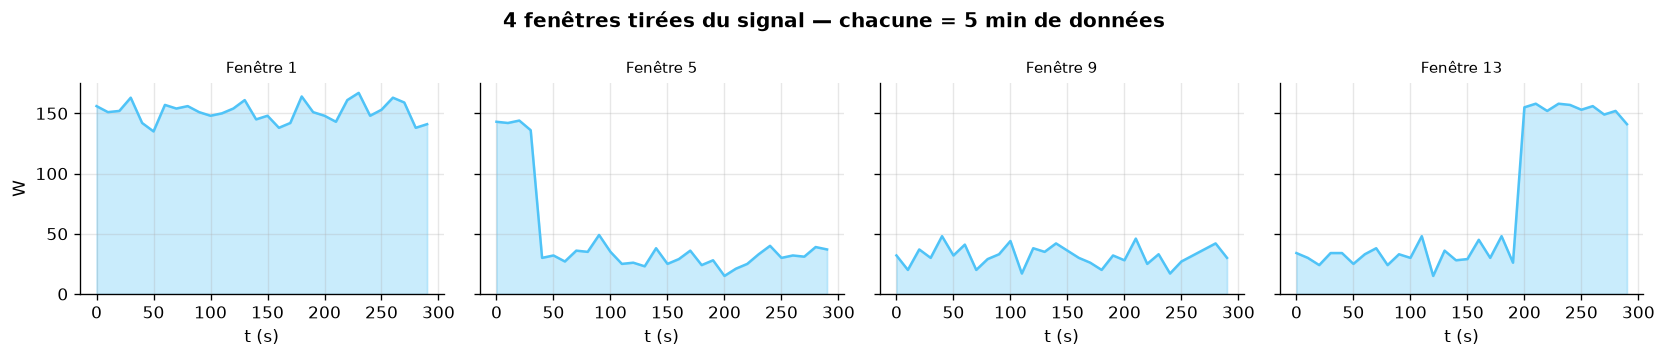


Chaque fenêtre est un vecteur de 30 valeurs : c'est ce qu'on va analyser.
Certaines sont 'tout ON', d'autres 'tout OFF', d'autres mixtes (transition).


In [18]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import windowing as W

# Remettre les timestamps en string ISO pour windowing.py (son format d'entrée)
df_str = df.copy()
df_str['timestamp'] = df_str['timestamp'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
df_str['valeur_W'] = df_str['valeur_W'].astype(float)

fenetres = W.slice_fixed(df_str, window_s=300, step_s=150)

print(f"Signal de {N} points → {len(fenetres)} fenêtres de 5 min")
print(f"Chaque fenêtre : {fenetres[0]['n_points']} points")

# Regarder quelques fenêtres
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for i, ax in enumerate(axes):
    f = fenetres[i * 4]
    t_rel = [j * 10 for j in range(f['n_points'])]   # temps relatif en secondes
    ax.plot(t_rel, f['values'], color='#4fc3f7', lw=1.5)
    ax.fill_between(t_rel, f['values'], alpha=0.3, color='#4fc3f7')
    ax.set_title(f'Fenêtre {i*4+1}', fontsize=9)
    ax.set_xlabel('t (s)')
    if i == 0:
        ax.set_ylabel('W')
    ax.set_ylim(bottom=0)

fig.suptitle('4 fenêtres tirées du signal — chacune = 5 min de données', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nChaque fenêtre est un vecteur de 30 valeurs : c'est ce qu'on va analyser.")
print("Certaines sont 'tout ON', d'autres 'tout OFF', d'autres mixtes (transition).")

In [19]:
qcm(
    "On utilise des fenêtres de 5 min avec un pas de 2 min 30. "
    "Combien de fenêtres couvrent un point situé au milieu d'une plage de données normale ?",
    [
        "1 fenêtre — chaque point n'appartient qu'à une seule fenêtre",
        "2 fenêtres — grâce au chevauchement de 50 %",
        "3 fenêtres ou plus",
        "Ça dépend de la puissance à ce point",
    ],
    correct=1,
    explication="Avec 50 % de chevauchement (pas = moitié de la fenêtre), chaque point est "
                "couvert par exactement 2 fenêtres consécutives. Aucun événement ne tombe "
                "entièrement dans un 'trou' entre deux fenêtres."
)

## 1.7 · Features — résumer une fenêtre en quelques nombres

Une fenêtre = 30 valeurs. Un algorithme de ML préfère un **vecteur compact** de caractéristiques.  
On appelle ça des *features* (ou descripteurs).

L'idée : deux fenêtres du même état (ex: compresseur ON) doivent donner  
des features **proches** ; deux états différents doivent donner des features **éloignées**.

On commence par regarder **moyenne vs écart-type** en détail. Ensuite, à toi de refaire  
la même analyse avec **moyenne vs amplitude**.

Distribution : {'OFF': 127, 'ON': 63}

Features moyennes par état :
      moyenne  ecart_type  amplitude
etat                                
OFF      38.1        17.8       59.6
ON      136.5        25.8       83.5


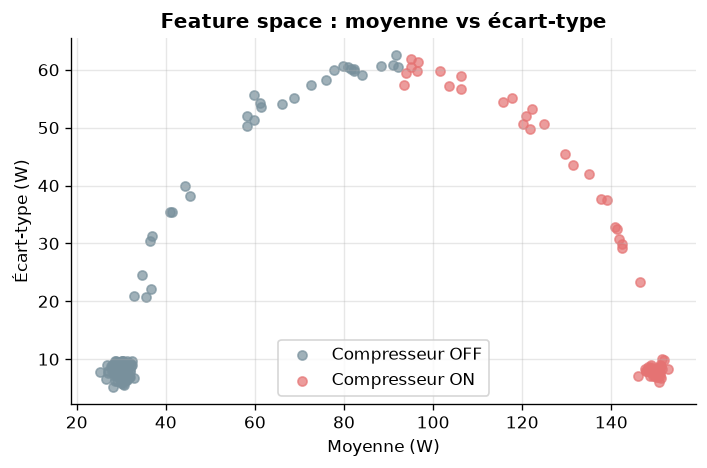

Les deux états sont bien séparés dans cet espace : la moyenne à elle seule fait presque tout le travail.


In [20]:
def features_simples(valeurs):
    """Calcule quelques features statistiques sur une fenêtre."""
    v = np.array(valeurs)
    return {
        'moyenne':   v.mean(),
        'ecart_type': v.std(),
        'minimum':   v.min(),
        'maximum':   v.max(),
        'amplitude': v.max() - v.min(),    # max - min
    }

# Calculer les features de chaque fenêtre
feats_list = [features_simples(f['values']) for f in fenetres]
df_feats = pd.DataFrame(feats_list)

# Labelliser chaque fenêtre selon l'état majoritaire du compresseur
labels = []
for f in fenetres:
    v = np.array(f['values'])
    labels.append('ON' if (v > SEUIL).mean() > 0.5 else 'OFF')

df_feats['etat'] = labels
print(f"Distribution : {df_feats['etat'].value_counts().to_dict()}")
print()
print("Features moyennes par état :")
print(df_feats.groupby('etat')[['moyenne', 'ecart_type', 'amplitude']].mean().round(1).to_string())

# Nuage de points : moyenne vs écart-type — est-ce que les états sont séparables ?
couleurs = {'ON': '#e57373', 'OFF': '#78909c'}

fig, ax = plt.subplots(figsize=(6, 4))
for etat, grp in df_feats.groupby('etat'):
    ax.scatter(grp['moyenne'], grp['ecart_type'],
               c=couleurs[etat], label=f'Compresseur {etat}', alpha=0.7, s=30)
ax.set_xlabel('Moyenne (W)')
ax.set_ylabel('Écart-type (W)')
ax.set_title('Feature space : moyenne vs écart-type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Les deux états sont bien séparés dans cet espace : la moyenne à elle seule fait presque tout le travail.")

**Vérifie ta compréhension** — imagine une nouvelle fenêtre, pas encore vue,
avec une **moyenne de 142 W** et un **écart-type de 9 W**.

In [21]:
qcm(
    "D'après le nuage de points ci-dessus (SEUIL = 90 W), comment cette fenêtre "
    "(moyenne = 142 W, écart-type = 9 W) sera-t-elle classée ?",
    [
        "ON — sa moyenne est nettement au-dessus du seuil de 90 W, dans le cluster rouge",
        "OFF — son écart-type est trop faible pour être ON",
        "Impossible à dire sans connaître l'amplitude",
        "OFF — 142 W est trop proche de 150 W pour être fiable",
    ],
    correct=0,
    explication="Le cluster ON est centré autour de 150 W avec un faible écart-type "
                "(le bruit gaussien fait ±8 W). Une moyenne de 142 W est largement "
                "au-dessus du seuil de 90 W : cette fenêtre tombe dans le cluster ON, "
                "et son écart-type de 9 W est cohérent avec ce cluster."
)

**À toi de jouer** — `df_feats` est déjà calculé et contient les colonnes `moyenne`,
`ecart_type`, `amplitude` et `etat`. Dans la cellule vide ci-dessous, reproduis le même
type de nuage de points que ci-dessus, mais avec **`amplitude`** sur l'axe Y au lieu de
`ecart_type`. Les états sont-ils aussi bien séparés qu'avec l'écart-type ?

In [22]:
# Cellule libre — trace ici le nuage de points moyenne vs amplitude



In [23]:
qcm(
    "Pour distinguer compresseur ON (~150 W) de compresseur OFF (~30 W), "
    "quelle feature est la plus utile ?",
    [
        "L'amplitude (max − min), car elle mesure la variabilité",
        "La moyenne, car elle reflète directement le niveau de puissance",
        "L'écart-type, car il mesure le bruit",
        "Le minimum, car il est toujours à 0 W quand c'est OFF",
    ],
    correct=1,
    explication="La moyenne de la fenêtre sera ~150 W si le compresseur tourne, ~30 W sinon. "
                "C'est la feature la plus directement discriminante ici. "
                "L'amplitude est utile quand il y a des transitions dans la fenêtre, "
                "mais pas pour des fenêtres purement ON ou purement OFF."
)